# Assignment 04
## Computational Linguistics
SoSe2025


## Requirements
Your code will be graded during a "Testat" by one of the tutors. For each task we'll ask a random member of your group to walk us through your code and explain what you did. No need to prepare a presentation.
- Make sure that everyone in the group can explain the code. Your grade depends on both explanation and code
- If your code doesn't run, you can maximally get half of the points

The deadline is the 27th of July at 23.59h

Welcome to this assignment.
You can check-off tasks by clicking into the text blocks and placing an x between the brackets

- [ ] not checked off
- [x] checked off

In [65]:
### import libraries ###
import nltk
from nltk.util import ngrams
from nltk.probability import FreqDist
from collections import defaultdict
from collections import Counter
import numpy as np
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/mustafa/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

--------------------------------------------------------------

## Task 1 - Text classification of n-gram model output
### Outline
We want to check, whether a Naive Bayes classifier can distinguish the output of two different n-gram models.
For this we'll start with preprocessing the two corpora: shakespeare and reuters. For each of them we build one n-gram model. After that we'll have the two n-gram models output a few sentences, which we'll then classify with a Naive Bayes classifier.


----------------------------------------------------------

### Task 1.1 - Load corpora and pre-processing (2 points)

Reuters corpus is a collection of thousands of news documents from the Reuters newswire, labeled with topics, for research and text categorization tasks.

Shakespeare corpus provides a subset of Shakespeare works such as Hamlet or MacBeth.

-  [x] load reuters corpus from nltk
- [x] load shakespeare corpus from nltk
- [x] improve pre-processing function by one additional filter/nuance (you can get inspiration from the preprocessing with regex slides)
- [x] apply pre-processing function to both corpora


<details>
<summary><span style="color: green; font-weight: bold;">Reasoning</span></summary>

**1. Clear task statement**

There are many preprocessing techniques; we only keep those that fit **this** pipeline:

**preprocess → n-gram model → generate sentences → Naive Bayes classify**

The same preprocessed text is reused for:

- **N-gram counts** (Task 1.2)
- **Text generation** (Task 1.3)
- **Naive Bayes word probabilities** (Task 1.4–1.5)

So preprocessing must work for **language modeling and classification together**, not for one step alone.

**2. What matters in our case**

**General**

- Use **one `preprocess()` function** for both Reuters and Shakespeare.
- Keep **meaningful word tokens**; remove formatting noise, not stylistic differences.
- Clean raw text with **regex before tokenization** so tokenization starts from stable input (e.g. normalized whitespace).
- Do **not** stem/lemmatize or remove generic stopwords (`the`, `of`, `to`) — they are needed for n-grams and appear in our sentence starters.

**N-gram counts**

- Tokens must be clean and consistent so trigram/bigram frequencies are reliable.
- Frequent markup/boilerplate words (`speaker`, `company`, `said`, …) would dominate counts and create useless patterns.

**Text generation**

- Generation picks the most frequent matching n-grams, so noisy high-frequency tokens cause loops like *"the company said the company said …"*.
- We must keep starter words such as `the`, `a`, `to`, `be`, `or`.

**Naive Bayes word probabilities**

- We need word-level evidence that still reflects corpus style (news vs plays).
- Over-cleaning would remove useful differences; under-cleaning adds probability mass to non-content tokens.

**3. Final preprocessing decision**

| Step | Technique | Why |
|---|---|---|
| 1 | Tokenization (`word_tokenize`) | Split cleaned text into words |
| 2 | Lowercasing | Reduce sparsity; same token for `Market` / `market` |
| 3 | Alphabetic filter (`isalpha`) | Remove punctuation and numbers |
| 4 | Blocklist (`filter_out_words`) | Remove corpus markup/boilerplate (`ltd`, `stagedir`, …) |
| 5 | **Minimum length filter** | Drop 1-character noise; keep `a` and `i` for valid starters |
| 6 | **Regex cleanup before tokenization** | Clean raw text with `re.sub(r'\s+', ' ', text)` to normalize whitespace before splitting |

**Not used:** stemming/lemmatization, NLTK stopword removal, different rules per corpus.

</details>

In [66]:
import re
from nltk.corpus import reuters
from nltk.corpus import shakespeare


# Download the 'reuters' corpus if not already downloaded
nltk.download('reuters')

# Your shakespeare download here
nltk.download('shakespeare')

# Load the corpus
reuters_documents = reuters.fileids()
shakespeare_documents = shakespeare.fileids()  # Your code here

# Preprocess the corpus: Tokenize, lowercase, and remove punctuation/numbers.
filter_out_words = [
    'ltd', 'stagedir',
    # Task 1.3.4: high-frequency boilerplate that dominated generation and caused loops
    'said', 'speech', 'speaker', 'line', 'dlr', 'pct', 'scene', 'company',
]
def preprocess(document: str) -> list[str]:
    """Args: document — raw text string. Returns: list of cleaned lowercase tokens."""
    # Your additional pre-processing here
    # Regex cleanup before tokenization
    document = re.sub(r'\s+', ' ', document).strip()

    # Tokenization
    tokens = nltk.tokenize.word_tokenize(document)
    tokens = [
        word.lower() for word in tokens  # Lowercasing
        if word.isalpha()  # Alphabetic filter
        and word.lower() not in filter_out_words  # Blocklist
        and (len(word) >= 2 or word.lower() in {'a', 'i'})  # Minimum length filter
    ]

    return tokens

# Apply preprocessing to all documents
processed_reuters = [preprocess(reuters.raw(doc_id)) for doc_id in reuters_documents]
processed_shakespeare = [  # Your code here
    preprocess(' '.join(shakespeare.words(doc_id)))
    for doc_id in shakespeare_documents
]


print(f"Number of documents in the Reuters corpus: {len(processed_reuters)}")
print(f"Number of documents in the Shakespeare corpus: {len(processed_shakespeare)}")
print(f"First Reuters document: {' '.join(processed_reuters[0])}")
print(f"First Shakespeare document: {' '.join(processed_shakespeare[0])}")

[nltk_data] Downloading package reuters to /Users/mustafa/nltk_data...
[nltk_data]   Package reuters is already up-to-date!
[nltk_data] Downloading package shakespeare to
[nltk_data]     /Users/mustafa/nltk_data...
[nltk_data]   Package shakespeare is already up-to-date!


Number of documents in the Reuters corpus: 10788
Number of documents in the Shakespeare corpus: 8
First Reuters document: asian exporters fear damage from rift mounting trade friction between the and japan has raised fears among many of asia exporting nations that the row could inflict economic damage businessmen and officials they told reuter correspondents in asian capitals a move against japan might boost protectionist sentiment in the and lead to curbs on american imports of their products but some exporters that while the conflict would hurt them in the in the tokyo loss might be their gain the has it will impose mln dlrs of tariffs on imports of japanese electronics goods on april in retaliation for japan alleged failure to stick to a pact not to sell semiconductors on world markets at below cost unofficial japanese estimates put the impact of the tariffs at billion dlrs and spokesmen for major electronics firms they would virtually halt exports of products hit by the new taxes w

------------------------------------------------------------

### Task 1.2 - build n-gram models (3 points)
take the n-gram model code below from the second assignment and complete the following tasks:
- [x] turn the quadgram model into a  model that can calculate both trigrams and bigrams (also rename the function to create_ngrams for better overview)
- [x] save a trigram model trained on the preprocessed shakespeare corpus / reuters corpus into trigrams_shakespeare / trigrams_reuters
- [x] save a bigram models trained on the preprocessed shakespeare corpus / reuters corpus into bigrams_shakespeare / bigrams_reuters
- [x] calculate all trigram / bigram frequencies in the second cell below

<details>
<summary><span style="color: green; font-weight: bold;">Reasoning</span></summary>

**`ngrams` function documentation**

NLTK function that builds overlapping word tuples of size `n` from a token list.

| Argument | What it does |
|---|---|
| `sequence` | One document as a list of tokens |
| `n` | N-gram size (`2` = bigram, `3` = trigram) |
| `pad_left` / `pad_right` | Add n-grams at sentence start/end |
| `left_pad_symbol` / `right_pad_symbol` | Padding tokens — we use `'<s>'` and `'</s>'` |

Padding teaches the model how sentences begin and end (needed in Task 1.3).
</details>

In [68]:
# Function to create n-grams from the processed corpus
# adapt this function to create ngrams
def create_ngrams(corpus: list[list[str]], n: int) -> list[tuple[str, ...]]:
    """
    Args:
        corpus: list of documents; each document is a list of tokens
        n: n-gram size (2 = bigram, 3 = trigram)
    Returns:
        flat list of n-gram tuples from all documents
    """
    all_ngrams = []

    for document in corpus:
        # Create ngrams with padding for each document
        doc_ngrams = list(
            ngrams(
                document, n,
                pad_left=True, pad_right=True,  # Sentence padding
                left_pad_symbol='<s>', right_pad_symbol='</s>'  # Start/end markers for generation
            )
        )
        # Collect n-grams from all documents into one flat list
        all_ngrams.extend(doc_ngrams)

    return all_ngrams

# Generate trigrams
reuters_trigrams = create_ngrams(processed_reuters, 3)
shakespeare_trigrams = create_ngrams(processed_shakespeare, 3)

# Generate bigrams
reuters_bigrams = create_ngrams(processed_reuters, 2)
shakespeare_bigrams = create_ngrams(processed_shakespeare, 2)

<details>
<summary><span style="color: green; font-weight: bold;">Reasoning</span></summary>

**`FreqDist` / `calculate_ngram_freq` documentation**

`FreqDist` from `nltk.probability` counts how often each item appears in a list.

| Input / method | What it does |
|---|---|
| `samples` | Iterable to count — we pass all n-gram tuples from one corpus |
| `FreqDist(...)` | Builds a mapping: n-gram tuple → count |
| `.most_common(n)` | Returns the `n` most frequent n-grams with their counts |

`calculate_ngram_freq` wraps `FreqDist` to turn a flat n-gram list into a frequency table for Task 1.3 — generation picks the most common matching continuation.

</details>

In [69]:
# Function to calculate n-gram frequency
def calculate_ngram_freq(samples: list[tuple[str, ...]]) -> FreqDist:
    """
    Args:
        samples: flat list of n-gram tuples to count
    Returns:
        FreqDist mapping each n-gram to its count in the corpus
    """
    return FreqDist(samples)

# Calculate frequency of our trigrams
reuters_trigram_freq = calculate_ngram_freq(reuters_trigrams)
shakespeare_trigram_freq = calculate_ngram_freq(shakespeare_trigrams)

# Calculate frequency of our bigrams
reuters_bigram_freq = calculate_ngram_freq(reuters_bigrams)
shakespeare_bigram_freq = calculate_ngram_freq(shakespeare_bigrams)

# Show the 10 most common trigrams
print(f"Most common Reuters trigrams: {reuters_trigram_freq.most_common(10)}")
print(f"Most common Shakespeare trigrams: {shakespeare_trigram_freq.most_common(10)}")

Most common Reuters trigrams: [(('mln', 'vs', 'mln'), 3400), (('cts', 'vs', 'cts'), 1779), (('revs', 'mln', 'vs'), 1514), (('shr', 'cts', 'vs'), 1446), (('vs', 'cts', 'net'), 1169), (('cts', 'net', 'vs'), 1082), (('of', 'mln', 'dlrs'), 1061), (('net', 'vs', 'revs'), 887), (('mln', 'dlrs', 'in'), 828), (('vs', 'revs', 'mln'), 709)]
Most common Shakespeare trigrams: [(('i', 'pray', 'you'), 72), (('my', 'lord', 'hamlet'), 64), (('i', 'can', 'not'), 51), (('i', 'do', 'not'), 46), (('i', 'will', 'not'), 45), (('i', 'know', 'not'), 38), (('it', 'is', 'a'), 35), (('i', 'have', 'a'), 35), (('my', 'lord', 'i'), 35), (('i', 'would', 'not'), 34)]




---------------------------------------------------

### Task 1.3 - generate test data (7 Points)
In this task we'll get a few outputs from both the shakespeare and the reuters n-gram model.
Later we'll use these model outputs to test our Naive Bayes classifier, which is why we call the sentences generated in this task "test_data"

#### Task 1.3.1 Predict next word (3 Points)
In the cell below, you can find a method, that implements the prediction of a single next word  

- [x] Implement the code to use bigram probability if a matching trigram could not be found
- [x] Does your addition implement a form of interpolation or backoff? Write a one sentence justification.

**Backoff** — the model tries trigram lookup first and only falls back to bigram frequencies (then the global most-common bigram) when no matching trigram exists, rather than combining trigram and bigram probabilities into a weighted estimate.

In [70]:
# Create a simple predictive text model based on ngram frequency
def best_continuation(ngram_frequencies: FreqDist, context: tuple[str, ...]) -> str | None:
    """Return the highest-frequency word following `context`, or None if no ngram matches.

    Args:
        ngram_frequencies — frequency distribution of ngrams (tuples of words).
        context — the leading words to match against each ngram's prefix.
    Returns:
        The most frequent continuation word, or None when no ngram starts with `context`.
    """
    # Find all ngrams whose leading words match the context, keeping their counts
    matches = {}
    for ngram, frequency in ngram_frequencies.items():
        if ngram[:-1] == context:
            matches[ngram] = frequency

    if not matches:
        return None

    # Select the ngram with the highest frequency and return its last word
    best_ngram = max(matches, key=matches.get)
    return best_ngram[-1]


def predict_next_word(
    words: list[str],
    trigram_frequencies: FreqDist,
    bigram_frequencies: FreqDist,
) -> str:
    """Predict the next word for a context using trigram lookup with bigram backoff.

    Args:
        words — the context words generated so far.
        trigram_frequencies — frequency distribution of trigrams.
        bigram_frequencies — frequency distribution of bigrams.
    Returns:
        The predicted next word.
    """
    # Step 1: Try trigram lookup (context = last 2 words, even if words is longer)
    prediction = best_continuation(trigram_frequencies, tuple(words[-2:]))
    if prediction is not None:
        return prediction

    # Step 2: No matching trigram; back off to the most common bigram where
    # the first word matches words[-1]
    prediction = best_continuation(bigram_frequencies, (words[-1],))
    if prediction is not None:
        return prediction

    # Step 3: Fallback when no matching bigram exists
    # Fallback: just use the second word of the most common bigram
    print("No bigram starting with '{}', used most common bigram.".format(words[-1]))
    return bigram_frequencies.most_common(1)[0][0][1]


#### Tests for Task 1.3.1
Small hand-built `FreqDist`s to check each path: trigram hit, bigram backoff, and the most-common-bigram fallback.

In [71]:
# Tests for predict_next_word / best_continuation
# Build tiny frequency distributions so we control which ngrams exist.
test_trigrams = FreqDist({
    ('the', 'stock', 'market'): 12,
    ('the', 'stock', 'price'): 5,
    ('in', 'the', 'morning'): 7,
})
test_bigrams = FreqDist({
    ('stock', 'market'): 20,
    ('market', 'crash'): 3,
    ('good', 'morning'): 50,   # most common bigram overall -> used by the fallback
})

# best_continuation: returns the highest-frequency continuation, or None if no match
assert best_continuation(test_trigrams, ('the', 'stock')) == 'market'
assert best_continuation(test_bigrams, ('market',)) == 'crash'
assert best_continuation(test_trigrams, ('no', 'match')) is None

# Step 1: a matching trigram is used (market has higher count than price)
assert predict_next_word(['the', 'stock'], test_trigrams, test_bigrams) == 'market'

# Step 2: no trigram match -> back off to a bigram starting with the last word
assert predict_next_word(['big', 'market'], test_trigrams, test_bigrams) == 'crash'

# Step 3: no trigram and no matching bigram -> fallback to most common bigram's 2nd word
assert predict_next_word(['big', 'zzz'], test_trigrams, test_bigrams) == 'morning'

print("All Task 1.3.1 tests passed.")


No bigram starting with 'zzz', used most common bigram.
All Task 1.3.1 tests passed.


#### Task 1.3.2 Generate text (2 Points)
predict_next_word() only predicts a single next word. Write a function that uses predict_next_word() repeatedly. The output is the list generated_text that should contain the list of generated words (in order of generation).

- [x] write the function generate_text[]
- [x] within the function call the function predict_next_word() and give it the right arguments

In [72]:
# generate text until end_token (here </s>) is reached or the length is 20 words
def generate_text(
    start_words: list[str],
    trigram_frequencies: FreqDist,
    bigram_frequencies: FreqDist,
    max_length: int = 20,
    end_token: str = '</s>',
) -> list[str]:
    """Generate text by repeatedly predicting the next word from the growing context.

    Args:
        start_words — the initial context words to begin generation from.
        trigram_frequencies — frequency distribution of trigrams.
        bigram_frequencies — frequency distribution of bigrams.
        max_length — maximum number of words in the returned list.
        end_token — stop generating once this token is predicted.
    Returns:
        The generated words (including start_words), in order of generation.
    """
    # Copy the seed words so we don't mutate the caller's list
    generated_text = list(start_words)

    # Keep predicting the next word until we hit the end token or the length limit.
    # predict_next_word() reads the trigram/bigram context from the last words for us.
    while len(generated_text) < max_length:
        next_word = predict_next_word(generated_text, trigram_frequencies, bigram_frequencies)
        if next_word == end_token:
            break
        generated_text.append(next_word)

    return generated_text


#### Task 1.3.3 Generate test data ( 1 Points)
- [ ] use the function from above to have each of the two n-gram models generate 10 output sentences from sentence_starters and save the outputs into test_data_shakespeare and test_data_reuters

In [73]:
test_data_reuters = []
test_data_shakespeare = []

sentence_starters = [
    ['the', 'price', 'of'],
    ['my', 'aunt'],
    ['the', 'next'],
    ['all', 'unicorns'],
    ['computers'],
    ['a', 'friend'],
    ['speaking', 'of'],
    ['to', 'be', 'or'],
    ['news', 'of'],
    ['today', 'is']

]

# iterate through the sentence starters and append the model's predictions to the test data
for item in sentence_starters:
  test_data_reuters.append(generate_text(item, reuters_trigram_freq, reuters_bigram_freq))
  test_data_shakespeare.append(generate_text(item, shakespeare_trigram_freq, shakespeare_bigram_freq))


#this looks ugly, but it's just for printing the test data you generated
print()
print('_'*40 + "\n")
print("Test data for Reuters")
for sentence in test_data_reuters:
  print('- '+' '.join(sentence))
print('_'*40 + "\n")
print("Test data for Shakespeare")
for sentence in test_data_shakespeare:
  print('- '+' '.join(sentence))

No bigram starting with 'aunt', used most common bigram.
No bigram starting with 'unicorns', used most common bigram.
No bigram starting with 'computers', used most common bigram.

________________________________________

Test data for Reuters
- the price of dlrs or cts a share in the first quarter of the total outstanding common stock the the
- my aunt the dollar was at about mln dlrs in the first quarter of the total outstanding common stock the
- the next few months ago the energy department agency distillate demand was mln dlrs in the first quarter of the
- all unicorns the dollar was at about mln dlrs in the first quarter of the total outstanding common stock the
- computers the merger is subject to approval by the end of the total outstanding common stock the the transaction is
- a friend of walywn stodgell cochran murray institutional buyers will be used to reduce the trade deficit with japan which
- speaking of the total outstanding common stock the the transaction is subject 

#### Task 1.3.4 Tuning the model output (1 Points)
You might have noticed a few redundant words like "speaker", "speech" and loops like "the company said the company said".

- [x] add ['said', 'speech', 'speaker', 'line', 'dlr', 'pct', 'scene', 'company'] to the words you filter out in the preprocessing step
- [x] run the entire notebook again

Think about why these words appear so frequently. You can filter additional words if you find them annoying.

**Why these words appear so frequently:**

- **Reuters** — financial boilerplate: `said` (reporting verb), `dlr`/`pct` (units), and `company` repeat in almost every report.
- **Shakespeare** — `speech`, `speaker`, `scene`, `line` are XML markup tags, not real dialogue.

We filter out the eight given words but keep normal function words (`the`, `of`, `i`, `you`), since the n-grams and sentence starters need them. This removes the named loops, though greedy selection can still repeat the next-most-common phrase.


-----------------------------------------

### Task 1.4 - Train a Naive Bayes classifier (3 Points)
In this task we'll calculate all the probabilities the Naive Bayes model needs for classification.
The code in the following cells is very similar to the code in the third assignment. Feel free to get inspiration there if you're stuck.Try to do it yourself, if you want to learn something.

#### Task 1.4.1 Calculate the prior probability of each class (1 Points)

- [x] calculate the prior probality for reuters and shakespeare

In [74]:
#calculate the probability of a random document being part of either class
total_documents = len(processed_reuters) + len(processed_shakespeare)
prior_reuters = len(processed_reuters) / total_documents
prior_shakespeare = len(processed_shakespeare) / total_documents

print(f"Probability for class Reuters: {prior_reuters}")
print(f"Probability for class Shakespeare: {prior_shakespeare}")

Probability for class Reuters: 0.9992589848091886
Probability for class Shakespeare: 0.0007410151908114116


#### Task 1.4.2 Word frequencies in each class (1 Points)
- [x] count how many times each word occurs in each corpus


In [75]:
def count_words_in_corpus(corpus: list[list[str]]) -> Counter:
    """Count how many times each word occurs across all documents in a corpus.

    Args:
        corpus — preprocessed documents, each as a list of tokens.
    Returns:
        Counter mapping each word to its total count in the corpus.
    """
    word_counts = Counter()
    for document in corpus:
        word_counts.update(document)
    return word_counts


# Count number of occurences of words in reuters
reuters_words = count_words_in_corpus(processed_reuters)

# Count number of occurences of words in shakespeare
shakespeare_words = count_words_in_corpus(processed_shakespeare)

print("Most common Reuters words:", reuters_words.most_common(10))
print("Most common not Shakespeare words:", shakespeare_words.most_common(10))

Most common Reuters words: [('the', 69245), ('of', 36749), ('to', 36275), ('in', 29217), ('and', 25616), ('a', 24724), ('mln', 18598), ('vs', 14332), ('for', 13420), ('dlrs', 12329)]
Most common not Shakespeare words: [('the', 6210), ('and', 5549), ('i', 4849), ('to', 4239), ('of', 3439), ('a', 3052), ('you', 3011), ('my', 2531), ('that', 2429), ('in', 2364)]


#### Task 1.4.3 Total number of words in each class (0.5 Points)
 Note that these include multiple counts for multiple words
- [x] calculate the total number of words in each class

In [76]:
# Calculate total words in each class (counting multiple occurences as well)
total_reuters_words = sum(reuters_words.values())
total_shakespeare_words = sum(shakespeare_words.values())

print(f"Total words in Reuters: {total_reuters_words}")
print(f"Total words in Shakespeare: {total_shakespeare_words}")

Total words in Reuters: 1232351
Total words in Shakespeare: 191300


#### Task 1.4.4 Total vocabulary size (0.5 Points)
- [x] calculate the number of distinct words

In [77]:
# Combine the keys from both counters to get the total vocabulary
vocab_size = len(reuters_words.keys() | shakespeare_words.keys())
print(f"Total vocabulary size: {vocab_size}")

Total vocabulary size: 34521


### Task 1.5 - Naive Bayes classification (3 Points)
In this task we'll build the Naive Bayes classfier and have it classify the test_data from task 1.3 to see if it can distinguish the outputs of the Reuters vs. the Shakespeare Model

#### Task 1.5.1 Naive Bayes classifier (2 Points)
- [x] use np.log() to get the log probabilities of the prior
- [x] calculate the probability of each word occurring given both classes
- [x] add the log of that probability of each word to the class probability
- [x] return "REUTERS" if the sentence was more likely generated by the reuters trigram model and "SHAKESPEARE" if it was more likely generated by the shakespeare trigram model

In [78]:
def naive_bayes_classify(text: list[str]) -> str:
    """Classify a sentence as REUTERS or SHAKESPEARE using Naive Bayes.

    Args:
        text — the sentence to classify, as a list of word tokens.
    Returns:
        "REUTERS" or "SHAKESPEARE" — whichever class scores higher.
    """
    # Start with log probabilities of the prior
    log_prob_reuters = np.log(prior_reuters)
    log_prob_shakespeare = np.log(prior_shakespeare)

    # For each word, add log probability (like the big sum in the formula)
    for word in text:

        # Calculate P(word|reuters) with Laplace smoothing
        reuters_prob = (reuters_words[word] + 1) / (total_reuters_words + vocab_size)
        # Calculate P(word|shakespeare) with Laplace smoothing
        shakespeare_prob = (shakespeare_words[word] + 1) / (total_shakespeare_words + vocab_size)

        # Add log probabilities: This is where everything comes together
        log_prob_reuters += np.log(reuters_prob)
        log_prob_shakespeare += np.log(shakespeare_prob)

    # Return the prediction based on higher probability
    return "REUTERS" if log_prob_reuters > log_prob_shakespeare else "SHAKESPEARE"


#### Task 1.5.2 Naive bayes predictions (1 Point)
- [x] apply the naive bayes model to generate predictions for each sentence
- [x] store the prediction in reuters_predictions / shakespeare_predictions

In [79]:
def classify_sentences(sentences: list[list[str]], source_name: str) -> list[str]:
    """Classify each sentence, print the result, and return all predictions.

    Args:
        sentences — generated test sentences, each as a list of word tokens.
        source_name — label for the trigram model that produced the sentences (e.g. "Reuters").
    Returns:
        List of classifier labels ("REUTERS" or "SHAKESPEARE"), one per input sentence.
    """
    # Step 1: Prepare output list and print a header for this model's results
    predictions: list[str] = []
    print(f"Predictions for the sentences generated by the {source_name} trigram-model:")
    print("_" * 40 + "\n")

    # Step 2: Classify each sentence and record the prediction
    for sentence in sentences:
        prediction = naive_bayes_classify(sentence)
        predictions.append(prediction)
        print(f"Sentence: '{' '.join(sentence)}'")
        print(f"Prediction: {prediction}")
        print()

    # Step 3: Return all predictions for later evaluation (Task 1.6)
    return predictions

reuters_predictions = classify_sentences(test_data_reuters, "Reuters")
shakespeare_predictions = classify_sentences(test_data_shakespeare, "Shakespeare")

Predictions for the sentences generated by the Reuters trigram-model:
________________________________________

Sentence: 'the price of dlrs or cts a share in the first quarter of the total outstanding common stock the the'
Prediction: REUTERS

Sentence: 'my aunt the dollar was at about mln dlrs in the first quarter of the total outstanding common stock the'
Prediction: REUTERS

Sentence: 'the next few months ago the energy department agency distillate demand was mln dlrs in the first quarter of the'
Prediction: REUTERS

Sentence: 'all unicorns the dollar was at about mln dlrs in the first quarter of the total outstanding common stock the'
Prediction: REUTERS

Sentence: 'computers the merger is subject to approval by the end of the total outstanding common stock the the transaction is'
Prediction: REUTERS

Sentence: 'a friend of walywn stodgell cochran murray institutional buyers will be used to reduce the trade deficit with japan which'
Prediction: REUTERS

Sentence: 'speaking of the 

### Task 1.6 - Evaluation (5 Points)
As you can see, this classifiction worked very well. Still as a part of formal evaluation we'll calculate precision, recall and F1 for the naive bayes classifier.

#### Task 1.6.1 Function for calculating precision (1 Point)
- [x] write a function to calculate precision

In [80]:
def precision(true_positives: int, false_positives: int) -> float:
    """Precision = TP / (TP + FP): share of positive predictions that were correct.

    Args:
        true_positives — count of correctly predicted positives.
        false_positives — count of items wrongly predicted as positive.
    Returns:
        Precision as a float in [0, 1].
    """
    return true_positives / (true_positives + false_positives)


#### Task 1.6.2 Function for calculating recall (1 Point)

- [x] write a function to calculate recall

In [81]:
def recall(true_positives: int, false_negatives: int) -> float:
    """Recall = TP / (TP + FN): share of actual positives that were found.

    Args:
        true_positives — count of correctly predicted positives.
        false_negatives — count of positives that were missed.
    Returns:
        Recall as a float in [0, 1].
    """
    return true_positives / (true_positives + false_negatives)


#### Task 1.6.3 Function for calculating F1 ( 1 Point)
- [x] write a function to calculate F1

In [82]:
def f1(precision: float, recall: float) -> float:
    """F1 = 2 * P * R / (P + R): harmonic mean of precision and recall.

    Args:
        precision — the precision value.
        recall — the recall value.
    Returns:
        F1 score as a float in [0, 1].
    """
    return 2 * precision * recall / (precision + recall)


#### Task 1.6.4 Calculating metrics for the naive bayes classifier (2 Points)
Remember: each document correctly classified as Shakespeare or Reuters is a true positive. In total the naive bayes model classified 20 documents.

Using the true labels (the trigram model that actually generated the sentence) and the Naive Bayes model output:
- [x] calculate precision
- [x] calculate recall
- [x] calculate F1

In [83]:
# Precision, Recall and F1 measure for the naive bayes model classifications
# Each sentence correctly classified is a true positive; each mistake counts as
# both a false positive (for the class it was wrongly given) and a false negative
# (for its true class). 20 documents in total.
correct = (
    sum(label == "REUTERS" for label in reuters_predictions)
    + sum(label == "SHAKESPEARE" for label in shakespeare_predictions)
)
mistakes = len(reuters_predictions) + len(shakespeare_predictions) - correct

true_positives = correct
false_positives = mistakes
false_negatives = mistakes

precision_naive_bayes = precision(true_positives, false_positives)
recall_naive_bayes = recall(true_positives, false_negatives)
f1_naive_bayes = f1(precision_naive_bayes, recall_naive_bayes)

print(f"Precision for the naive bayes classifier: {precision_naive_bayes}")
print(f"Recall for the naive bayes classifier: {recall_naive_bayes}")
print(f"F1 for the naive bayes classifier: {f1_naive_bayes}")


Precision for the naive bayes classifier: 0.95
Recall for the naive bayes classifier: 0.95
F1 for the naive bayes classifier: 0.9500000000000001


All code above this cell was put toghether by Jeelka. If you spot any issues, please contact her by mail or on Telegram.  

## Task 2 Logistic Regression
In this task we want to build a Logistic Regresion model to classify the exact same test_sentences our trigram models generated in Task 1.
Let's see how this model is different!

### Task 2.1 - Prepare training data for logistic regression  (1  Point)

- [x] convert each document into a string and save it into training_texts (same list for both reuters and shakespeare)
- [x] append a 0 for a reuters sentence to training_labels and 1 for shakespeare

In [85]:
# Reuse existing preprocessed data - no need for separate function
training_texts = []
training_labels = []

# Add Reuters documents with label 0
for doc in processed_reuters:
    training_texts.append(' '.join(doc))
    training_labels.append(0)

# Add Shakespeare documents with label 1
for doc in processed_shakespeare:
    training_texts.append(' '.join(doc))
    training_labels.append(1)

print(f"Training data prepared:")
print(f"Total documents: {len(training_texts)}")
print(f"Reuters documents: {sum(1 for label in training_labels if label == 0)}")
print(f"Shakespeare documents: {sum(1 for label in training_labels if label == 1)}")

Training data prepared:
Total documents: 10796
Reuters documents: 10788
Shakespeare documents: 8


### Task 2.2 - Feature extraction using TF-IDF (1 Point)
TF-IDF is a vectorizer. Explain in one to three sentences why we need to vectorize the training data when we want to perform logistic regression. What is the difference to how we prepared the training data for the Naive Bayes model?

Your answer here: Logistic regression operates on numeric feature vectors (it computes `W · x + b`), so each document must be turned into a fixed-length numeric vector — TF-IDF does this by weighting each word/bigram. Naive Bayes needed no such step: it worked directly from raw per-class word counts and conditional probabilities, not from a feature matrix.

- [x] look up how the fit_transform() method of a TFidfVectorizer works and apply it to the training data

In [86]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,  # Limit to top 5000 features
    stop_words=None,    # We already preprocessed our text
    lowercase=False,    # We already lowercased
    ngram_range=(1, 2)  # Use both unigrams and bigrams
)

# Fit and transform training data
X_train = vectorizer.fit_transform(training_texts)
y_train = np.array(training_labels)

print(f"TF-IDF feature extraction completed:")
print(f"Feature matrix shape: {X_train.shape}")
print(f"Number of features: {X_train.shape[1]}")

TF-IDF feature extraction completed:
Feature matrix shape: (10796, 5000)
Number of features: 5000


### Task 2.3 - Train logistic regression model (1 Point)
This is where we train our logistic regression model on the training data. We're interested in the weights, biases for the predictions of test_data (and the loss to see how well our model performs on the training set)

- [x] find suitable hyperparameters

loss in epoch 0 is [-0.00077121]
loss in epoch 1 is [-4.21475636e-05]
loss in epoch 2 is [-0.00011589]
loss in epoch 3 is [-0.00013841]
loss in epoch 4 is [-0.00012202]
loss in epoch 5 is [-9.74563481e-05]
loss in epoch 6 is [-7.55086881e-05]
loss in epoch 7 is [-5.90786956e-05]
loss in epoch 8 is [-4.73839169e-05]
loss in epoch 9 is [-3.90483868e-05]


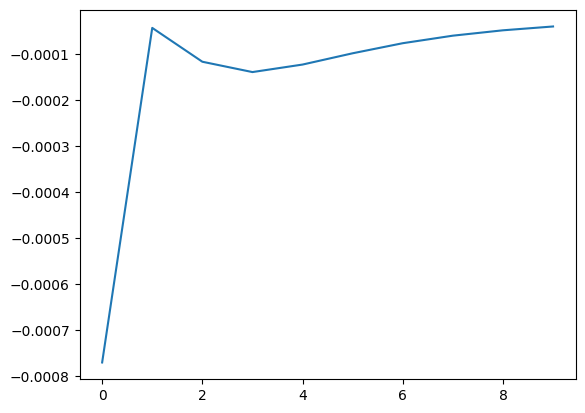

In [88]:
import matplotlib.pyplot as plt


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def predict(X, W, b):
    # Ensure X is treated as a sparse matrix if it is one
    z = X.dot(W) + b  # Use .dot() for sparse matrix multiplication
    return sigmoid(z)


def train(X, y, W, b, learning_rate=0.5, n_epochs=10):
    losses = []
    for epoch in range(n_epochs):
        epoch_loss = 0.0
        for i in range(X.shape[0]):
            x = X[i, :]  # Get the i-th row (document) as a sparse row vector
            yi = y[i]    # Get the corresponding label

            pred = predict(x, W, b)
            loss = yi - pred # Loss is target - prediction

            # compute gradients
            # Convert sparse row to dense array for element-wise multiplication
            dw = x.T.dot(loss) # Use dot for sparse matrix-vector multiplication
            db = loss # sum of errors for a single sample is just the error itself

            # update weights and bias
            W += learning_rate * dw  # Add gradient because loss is (y - pred)
            b += learning_rate * db  # Add gradient because loss is (y - pred)


            # accumulate loss
            epoch_loss += loss


        # normalize loss by number of samples
        epoch_loss /= X.shape[0]
        losses.append(epoch_loss)
        print(f"loss in epoch {epoch} is {epoch_loss}")
    return W, b, losses


# define model parameters
W = np.random.normal(0, 0.1, X_train.shape[1])
b = 0.0

# learning_rate=0.5 is the smallest rate that learns both classes; smaller rates
# (<=0.1) only ever predict the majority Reuters class. 10 epochs is past convergence.
W, b, losses = train(X_train, y_train, W, b, learning_rate=0.5, n_epochs=10)
plt.plot(losses)
plt.show()


### Task 2.4 - Prepare test data (1 Point)
- [ ] convert each test sentence into a string and save it into test_texts (same list for both reuters and shakespeare)
- [ ] append a 0 for a reuters sentence to test_labels and 1 for shakespeare
- [ ] transform the data using the same vectorizer as in Task 2.2

In [ ]:
# Reuse existing test data - no need for separate function
test_texts = []
test_true_labels = []

# Reuters generated sentences (label 0)
for sentence in test_data_reuters:
    pass # Your code here

# Shakespeare generated sentences (label 1)
for sentence in test_data_shakespeare:
    pass # Your code here

# Transform test data using the same vectorizer
X_test = "..."
y_test = "..."

print(f"Test data prepared:")
print(f"Total test sentences: {len(test_texts)}")
print(f"Reuters test sentences: {sum(1 for label in y_test if label == 0)}")
print(f"Shakespeare test sentences: {sum(1 for label in y_test if label == 1)}")

### Task 2.5 - Make predictions with logistic regression (1 Point)
This is where we predict the class of our test sentences

- [ ] obtain the predictions from the logistic regression model

In [ ]:
predictions = []
for X in X_test:
  prediction = None # Your code here
  predictions.append("SHAKESPEARE" if prediction >= 0.5 else "REUTERS")

# Just printing the results
print("Logistic Regression Predictions:")
print("_" * 40)
print()


print("Predictions for sentences generated by Reuters trigram model:")
print("_" * 40)
for i, sentence in enumerate(test_data_reuters):
    pred_label = predictions[i]
    print(f"Sentence: '{' '.join(sentence)}'")
    print(f"Prediction: {pred_label}")
    print()

print("_" * 40)
print()

print("Predictions for sentences generated by Shakespeare trigram model:")
print("_" * 40)
for i, sentence in enumerate(test_data_shakespeare):
    pred_label = predictions[i + len(test_data_reuters)]
    print(f"Sentence: '{' '.join(sentence)}'")
    print(f"Prediction: {pred_label}")
    print()

### Task 2.6 Balance training data (1 Point)
As you can hopefully see, the linear regression outputs everything as Reuters.
Write one to three sentences why this might be the case.
Then go to task 2.1 and make sure only the first eight reuters documents are selected as training data (keep the shakespeare data as it is).

Your answer here:

### Task 2.7 Evaluation (1 point)
- [ ] obtain the precision recall and f1 scores for the logistic regression model


In [ ]:
# Precision, Recall and F1 measure for the logistic regression model classifications
precision_log_reg = None
recall_log_reg = None
f1_log_reg = None

print(f"Precision for the naive bayes classifier: {precision_log_reg}")
print(f"Recall for the naive bayes classifier: {recall_log_reg}")
print(f"F1 for the naive bayes classifier: {f1_log_reg}")

## Task 3 Comparision (2 Points)
Compare the model outputs and explain if they are different. If yes, why?

Which model will be good for this task? Write your opinion down.

(Two to five sentences in total)